# Intro to Models
_written by Jaren N. Ashcraft_

`katsu` was originally written as a high-performance backend for functional Mueller calculus. This meant that we ignored "state" in lieu of developing the most rapid forward model we could for high-dimensional optimization. This choice resulted in difficult-to-customize code, so efforts were made to develop an object-oriented frontend for `katsu` to assist with fitting models to data.

This tutorial serves as an introduction to the `katsu.models` submodule, which provides a relatively lightweight and `jax`-able wrapper over `katsu.mueller` using `zodiax` to construct differentiable objects. 

Below is an example where we initialize a linear polarizer via the `LinearDiattenuator` class 

In [102]:
from katsu.models import LinearDiattenuator, LinearRetarder
from katsu.katsu_math import np, set_backend_to_jax

# Please don't eat all of my memory Jax 
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'


polarizer = LinearDiattenuator(transmission_axis=0, Tmin=0)

This object has a `matrix` attribute which stores the Mueller matrix computed in `katsu.mueller` 

In [103]:
polarizer.matrix

Array([[0.5, 0.5, 0. , 0. ],
       [0.5, 0.5, 0. , 0. ],
       [0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. ]], dtype=float64)

Thanks to zodiax, these objects work with our hot-swappable Jax backend. This needs to be done before initialization of the object, so unfortunately we do not support in-place data conversion.

In [104]:
set_backend_to_jax()
polarizer = LinearDiattenuator(transmission_axis=0, Tmin=0)
polarizer.matrix

Array([[0.5, 0.5, 0. , 0. ],
       [0.5, 0.5, 0. , 0. ],
       [0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. ]], dtype=float64)

Zodiax enables direct operations on our class attributes in a method reminiscent of operations on `jax` arrays. These include:
- `set`: which sets the new attribute
- arithmetic operations: `add`, `multiply`, `divide`, `power`
- simple analysis: `min`, `max`, `mean`

Use of these operations creates a new object with the updated attribute. See the appropriate use below for the `add` and `divide` methods

In [105]:
# Adding 1 to the matrix
polarizer = polarizer.add("matrix",1)
print(polarizer.matrix)
print(20*"-")

# subtracting 1 from the matrix
polarizer = polarizer.add("matrix", -1)
print(polarizer.matrix)
print(20*"-")

# Dividing by matrix element
polarizer = polarizer.divide("matrix", polarizer.matrix[0,0])
print(polarizer.matrix)
print(20*"-")

[[1.5 1.5 1.  1. ]
 [1.5 1.5 1.  1. ]
 [1.  1.  1.  1. ]
 [1.  1.  1.  1. ]]
--------------------
[[0.5 0.5 0.  0. ]
 [0.5 0.5 0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]]
--------------------
[[1. 1. 0. 0.]
 [1. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
--------------------


## Alternative Constructors and Matrix Multiplication
Both the `LinearDiattenuator` and `LinearRetarder` come with alternative constructors for simple methods.

In [106]:
pol_horizontal = LinearDiattenuator.as_polarizer(0)
qwp_45degree = LinearRetarder.as_quarter_wave_plate(np.radians(45))

print(pol_horizontal.matrix)
print(qwp_45degree.matrix)

[[0.5 0.5 0.  0. ]
 [0.5 0.5 0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]]
[[ 1.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00]
 [ 0.000000e+00  6.123234e-17  6.123234e-17 -1.000000e+00]
 [ 0.000000e+00  6.123234e-17  1.000000e+00  6.123234e-17]
 [ 0.000000e+00  1.000000e+00 -6.123234e-17  6.123234e-17]]


These objects inherit from a `MuellerMatrix` base class which supports matrix multiplication of optics. This allows for using the `@` matmul operator between `MuellerMatrix` elements.

In [107]:
circular_pol = qwp_45degree @ pol_horizontal
print(circular_pol.matrix)

[[5.000000e-01 5.000000e-01 0.000000e+00 0.000000e+00]
 [3.061617e-17 3.061617e-17 0.000000e+00 0.000000e+00]
 [3.061617e-17 3.061617e-17 0.000000e+00 0.000000e+00]
 [5.000000e-01 5.000000e-01 0.000000e+00 0.000000e+00]]


## Modeling multiple-state elements
One of the unique aspects of `katsu` is that the underlying operations are set up for automatic vectorization of linear algebra. This isn't hard, and just requires array bookkeeping by the user (i.e. keep the matrix dimensions in the last two axes of the array). But sometimes you don't want to keep track of axes because your brain is full of markov chains, and the front-end is here to help you with that.

Let's initialize the state of a full-stokes polarimeter, where a rotating quarter-wave plate is used in front of a stationary polarizer. We have a fixed position for the polarizer, but a variety of angles that the waveplate can take. If you look at the [Broadcasted Polarimetry Demo](../explanations/BroadcastedPolarimetry.ipynb), you'll know that `katsu` constructs Mueller matrices with a `shape` keyword to determine the broadcast dimensions of the Mueller matrix.

Using the ability to treat these objects as matrices, we can multiply them together and let our numpy-like backend handle the broadcasting! You'll notice that the shape of the resulting array `stokes_polarimeter` is now shape `(len(angles), 4, 4)`

In [108]:
angles = np.linspace(0, 2 * np.pi, 16)
waveplate_states = LinearRetarder.as_quarter_wave_plate(fast_axis=angles, shape=angles.shape)
polarizer = LinearDiattenuator.as_polarizer(transmission_axis=0.)

stokes_polarimeter =  polarizer @ waveplate_states
print(stokes_polarimeter.matrix.shape)

(16, 4, 4)


We can examine the observed power to plot the sinusoid that one would use to perform stokes polarimetry. Below we try this for a polarized and unpolarized stokes vector. The result is exactly what we would expect. A polarized source is modulated by the stokes polarimeter, whereas the unpolarized source experiences no modulation.

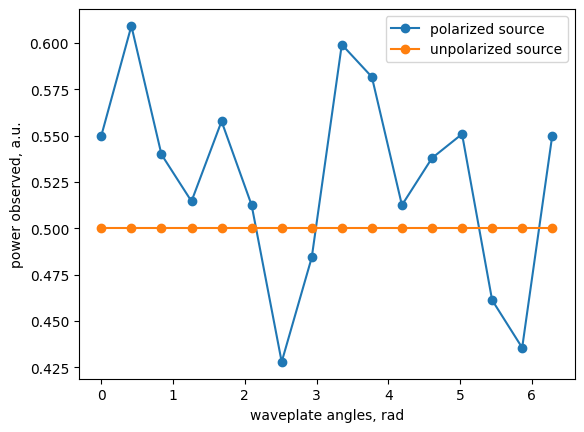

In [109]:
import matplotlib.pyplot as plt
stokes_pol = np.array([1, 0.1, 0.2, -0.1])
stokes_unpol = np.array([1, 0., 0., 0.])

# returns an ndarray if operated on with an ndarray
stokes_pol = stokes_polarimeter @ stokes_pol
stokes_unpol = stokes_polarimeter @ stokes_unpol

plt.figure()
plt.plot(angles, stokes_pol[..., 0], marker="o", label="polarized source")
plt.plot(angles, stokes_unpol[..., 0], marker="o", label="unpolarized source")
plt.xlabel("waveplate angles, rad")
plt.ylabel("power observed, a.u.")
plt.legend()
plt.show()

## Fitting a `Model` to Data 
To support optimization and statistical inference, we have a `Model` class that can simulate the power observed after a generally polarized source propagates through a system of Mueller matrices of arbitrary shape. Lets repeat this for the example of the Stokes polarimeter. The order is critical here, and will look "backwards" to some. 

Under the hood, Katsu is just looping over the optics in a list, meaning light (or your favorite stokes vector) encounters the first optic in the list, then the second, etc. 

We will start by generating our "truth" dataset using the standard `katsu` objects 

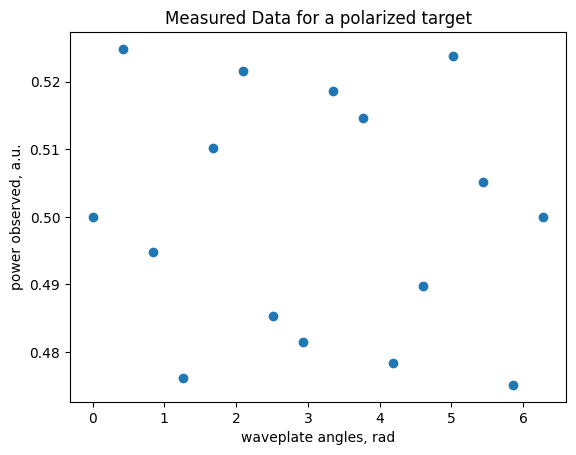

In [110]:
retarder = LinearRetarder.as_quarter_wave_plate(fast_axis=angles, shape=angles.shape)
polarizer = LinearDiattenuator.as_polarizer(0)
stokes = np.array([1., 0., 0.1, 0.])
stokes_after = polarizer @ retarder @ stokes
power_qwp = stokes_after[..., 0]

plt.figure()
plt.title("Measured Data for a polarized target")
plt.plot(angles, power_qwp, marker="o", linestyle="None")
plt.xlabel("waveplate angles, rad")
plt.ylabel("power observed, a.u.")
plt.show()

In the simplest case, let's say that we have some very good encoders that tell us the position of our waveplate, but we aren't quite confident of the waveplate's retardance. In addition, a postdoc came into our lab and bumped the polarizer - oh no! Now we need to use a new one and we don't know the angle or the diattenuation!

Luckily, we are observing something with very well defined polarization. Let's use that to unpack what the angle of our polarizer is. We begin, by constructing a model of our system. Here we initialize a `Model` that accepts a list of the objects we've previously defined.

Here is where [Zodiax](https://github.com/LouisDesdoigts/zodiax) comes in to help out with optimization. One of the sharp bits about Jax is that arrays and objects are fundamentally immutable, and Zodiax exists to help us take gradients with ease. Let's start by defining a `Model` using object layers, composed of a `Retarder` and a `Diattenuator`. 

In [111]:
# Called dLux for now before integration starts officially
from katsu.models import dLuxModel, dLuxDiattenuator, dLuxRetarder

layers = [
    ('retarder', dLuxRetarder(angles, np.pi, shape=angles.shape)),
    ('diattenuator', dLuxDiattenuator(0.1, 0.1)),
]

system = dLuxModel(layers)

Next we import the `optax` and `zodiax` libraries for minimization. `tqdm` is nice because we like progress bars.

In [112]:
import optax
import zodiax as zdx
import equinox as eqx
from tqdm import tqdm

Now we set up which parameters to optimize. We have a couple of options here thanks to `zodiax`. Option 1 is to define our parametes as a dictionary. NOTE: params values must be jax arrays, not raw python floats. `eqx.filter_value_and_grad` only differentiates array leaves, so a bare float (e.g. np.pi) is treated as a static constant and its gradient comes back as None.

In [113]:
# Option 1: We can chose what parameters we want to start from
params = {
    "retardance": np.array(np.pi / 2),
    "transmission_axis": np.array(0.7),
    "Tmin": np.array(0.5)
}

Option 2 is that we can grab the current model parameters that we defined earlier

In [114]:
# Option 2: We can take our starting parameters from the model
# (`get(..., as_dict=True)` already casts the values to float arrays)
params = system.get(["retardance", "transmission_axis", "Tmin"], as_dict=True)

Option 3 is to take our parameters from the model and store them in a dictionary ourselves

In [115]:
# Option 3: We can take our starting parameters from the model.
# Wrap in np.array so the leaves are differentiable (the raw attributes are
# python floats).
params = {
    "retardance": np.array(system.retarder.retardance),
    "transmission_axis": np.array(system.diattenuator.transmission_axis),
    "Tmin": np.array(system.diattenuator.Tmin)
}

Now we use `zodiax` to set up the optimization problem, and `optax` to optimize. Note that in this way, we can define different optimizers for each parameter if we so wish.

In [116]:
power_guess = system.forward(stokes=stokes)[:, 0]

# Utilize adam for optimization
optimizers = {
    "retardance": optax.adam(1e-2),
    "transmission_axis": optax.adam(1e-2),
    "Tmin": optax.adam(1e-2)
}

optim, state = zdx.optimisation.map_optimisers(params, optimizers)

# Define a loss function
def loss_fn(params, model, stokes):
    model = model.set(params)
    out = model.forward(stokes)
    observed = out[..., 0]
    return np.sum((observed - power_qwp) ** 2)


loss_grad_fn = eqx.filter_jit(eqx.filter_value_and_grad(loss_fn))
loss_grad_fn(params, system, stokes)


losses = []
for step in tqdm(range(400)):
    loss, grads = loss_grad_fn(params, system, stokes)
    updates, state = optim.update(grads, state)
    params = optax.apply_updates(params, updates)
    params["Tmin"] = np.clip(params["Tmin"], 1e-6, 1.0) 
    losses.append(loss)


100%|██████████| 400/400 [00:01<00:00, 277.46it/s]


Now that the Adam optimization has concluded we can simulate the power and see how well we did

In [117]:
# Update the system parameters
system = system.set(params)
power_after = system.forward(stokes)[:, 0]

We can see that we were pretty off with our starting guess, but our minimization routine converged right on the "True" measured power. This comes with the all-important caveat of being noiseless, which we will explore in the next example.

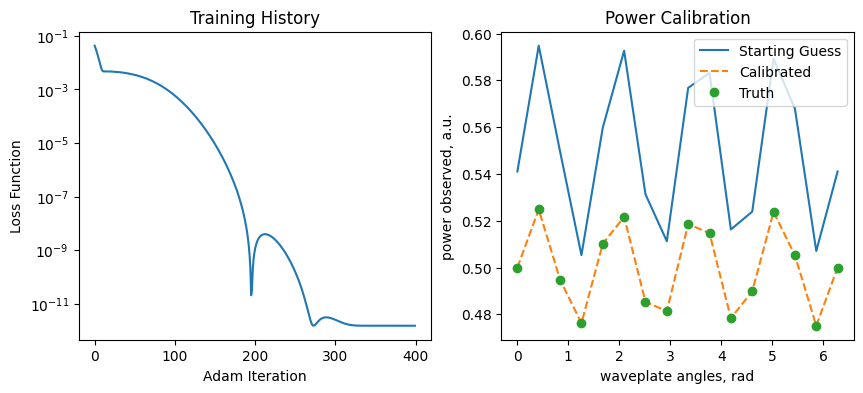

In [118]:
# Simulate the calibrated power
plt.figure(figsize=[10, 4])
plt.subplot(121)
plt.title("Training History")
plt.plot(losses)
plt.ylabel("Loss Function")
plt.xlabel("Adam Iteration")
plt.yscale("log")
plt.subplot(122)
plt.title("Power Calibration")
plt.plot(angles, power_guess, marker="None", linestyle="solid", label="Starting Guess")
plt.plot(angles, power_after, marker="None", linestyle="dashed", label="Calibrated")
plt.plot(angles, power_qwp, marker="o", linestyle="None", label="Truth")
plt.legend()
plt.xlabel("waveplate angles, rad")
plt.ylabel("power observed, a.u.")
plt.show()

## Posterior Sampling with Blackjax
Fast minimization is all well and good, but when calibrating polarimetric systems it can be nice to know how certain we are in our calirbation - rather than just what the solution is. This is where we bring in Markov-chain Monte Carlo (MCMC) techniques. Traditional MCMC techniques like the Metropolis-Hastings algorithm (as implemented in `emcee`) are a spectacular tool for a wide variety of cases. However, by leveraging the gradients we get from `jax` we can converge on solutions more efficiently. In this tutorial, we will use `blackjax` to leverage gradient information to sample our parameter space given the optimized parameters from above.


In [119]:
import blackjax
import jax

# Adam handed us a single best-fit point (the MAP estimate). To learn how
# *confident* we are in that calibration we sample the full posterior with
# blackjax's No-U-Turn Sampler (NUTS), which reuses the same jax gradients the
# optimiser did.

# Assumed 1-sigma measurement noise on each power reading. This sets the width
# of the Gaussian likelihood, i.e. how much the data is allowed to disagree
# with the model.
sigma = 0.02

# Our postdoc's polarizer turned out to be excellent: the fit drove Tmin onto
# its physical floor of 0. That floor is exactly where the sqrt(Tmin) term in
# the diattenuator's Mueller matrix has an infinite gradient, so we hold Tmin
# fixed at the fitted value and sample the two well-posed angles.
Tmin_fixed = float(np.clip(params["Tmin"], 1e-6, 1.0))


def log_posterior(theta):
    """Log-posterior of the sampled parameters `theta` (a dict)."""
    model = system.set({
        "retardance": theta["retardance"],
        "transmission_axis": theta["transmission_axis"],
        "Tmin": Tmin_fixed,
    })
    observed = model.forward(stokes)[..., 0]

    # Gaussian log-likelihood of the measured power
    log_like = -0.5 * np.sum(((observed - power_qwp) / sigma) ** 2)

    # Weakly-informative priors: we trust the optic is *approximately* a
    # quarter-wave plate, and the polarizer sits somewhere near horizontal.
    log_prior = (
        -0.5 * ((theta["retardance"] - np.pi / 2) / 0.3) ** 2
        - 0.5 * ((theta["transmission_axis"] - 0.0) / 0.5) ** 2
    )
    return log_like + log_prior


In [120]:
from blackjax.progress_bar import progress_bar_scan

# Start the chain from the optimised parameters
initial_position = {
    "retardance": np.asarray(params["retardance"]),
    "transmission_axis": np.asarray(params["transmission_axis"]),
}

key = jax.random.PRNGKey(0)

# `window_adaptation` is the Stan-style warmup: it auto-tunes the leapfrog step
# size and the mass matrix so we don't have to hand-tune the sampler.
key, warmup_key = jax.random.split(key)
warmup = blackjax.window_adaptation(
    blackjax.nuts, log_posterior, target_acceptance_rate=0.8
)
(last_state, tuned), _ = warmup.run(warmup_key, initial_position, num_steps=500)

# Build the tuned NUTS kernel and draw samples with lax.scan. blackjax's
# `progress_bar_scan` adds a tqdm bar from *inside* the compiled scan via a host
# callback, so we keep scan's speed. It needs two small tweaks: (1) scan over
# `(arange(num_samples), keys)` so it can read the iteration index, and (2) carry
# an extra `chain_id` (the -1) alongside the sampler state.
nuts = blackjax.nuts(log_posterior, **tuned)


def inference_loop(key, initial_state, num_samples):
    @progress_bar_scan(num_samples)
    def one_step(state, xs):
        _, key = xs
        state, info = nuts.step(key, state)
        return state, (state.position, info.is_divergent)

    keys = jax.random.split(key, num_samples)
    xs = (np.arange(num_samples), keys)
    _, (positions, divergent) = jax.lax.scan(one_step, (initial_state, -1), xs)
    return positions, divergent


key, sample_key = jax.random.split(key)
samples, divergent = inference_loop(sample_key, last_state, 4000)
print(f"drew {divergent.shape[0]} samples with {int(np.sum(divergent))} divergences")


<div><progress max="4000" value="4000"></progress> 100.00% [4000/4000 00:00&lt;?]</div>

drew 4000 samples with 0 divergences


### Visualizing the posterior

With samples in hand we can draw a *corner plot* with [`ChainConsumer`](https://samreay.github.io/ChainConsumer/) to read off the calibration uncertainties. The diagonal panels are the marginal distributions of each parameter (how well each is constrained on its own), and the off-diagonal panel shows their joint distribution (whether the two are correlated). The dashed lines mark the ground-truth values we used to generate the data — a trustworthy posterior should bracket them.

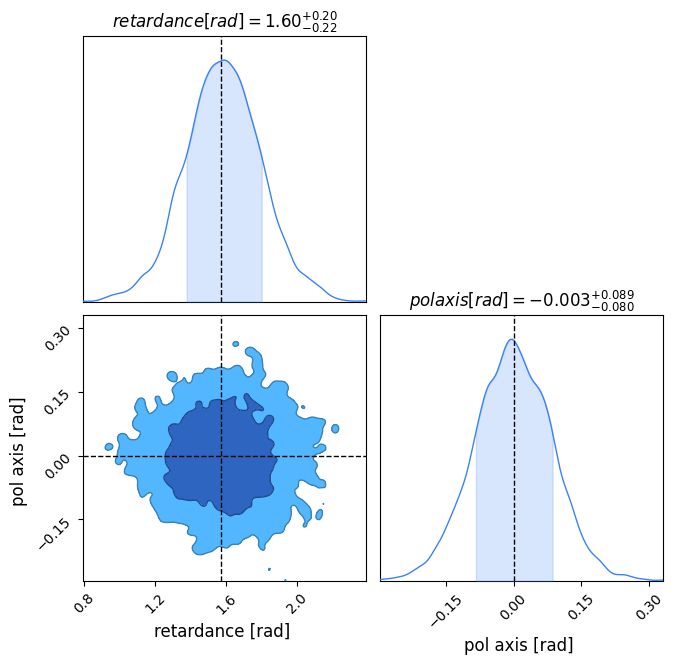

In [121]:
import pandas as pd
from chainconsumer import ChainConsumer, Chain, Truth

# ChainConsumer reads a DataFrame and uses the column names as axis labels.
# jax.device_get pulls the samples back to host numpy for plotting.
posterior = pd.DataFrame({
    "retardance [rad]": jax.device_get(samples["retardance"]),
    "pol axis [rad]": jax.device_get(samples["transmission_axis"]),
})

c = ChainConsumer()
c.add_chain(Chain(samples=posterior, name="NUTS posterior"))

# Overlay the ground-truth values we used to generate the data
c.add_truth(Truth(location={
    "retardance [rad]": float(np.pi / 2),
    "pol axis [rad]": 0.0,
}))

c.plotter.plot()
plt.show()


# Calibration with Fisher Information
Given a log-likelihood function $\mathcal{L}$ and analytic gradients, we can perform a degree of parameter inference without the relatively expensive MCMC algorithms. Instead, we perform maximum-likelihood optimization using the Fisher information matrix. It so happens that the _hessian_, $\nabla^2 \mathcal{L}$, is intrinsically the Fisher Information matrix, $\mathbf{F}$ under the Laplace approximation,

$$ \nabla^2 \mathcal{L} = \mathbf{F}.$$

In other words, if you are near the maximum likelihood, then the peak of the likelihood function is well-approximated by a multivariate normal - enabling the expeditious calculation of $\mathbf{F}$. This greatly simplifies maximum likelihood estimation, because we need only to run a minimization on the likelihood function, rather than perform an MCMC. The covariance matrix, $\mathbf{C}$ is then related to $\mathbf{F}$ by,

$$\mathbf{C} = -\mathbf{F}^{-1}.$$

Which we can turn into our corner plot. Let's run a minimization of the likelihood function to determine our maximum likelihood parameters

In [125]:
params = {
    "retardance": np.array(np.pi / 2),
    "transmission_axis": np.array(0.7),
}

# We are MAXIMISING the (log) posterior, so the minimiser works on its negative.
fun = lambda x: -1 * log_posterior(x)
loss_grad_fn = eqx.filter_jit(eqx.filter_value_and_grad(fun))

# Build a FRESH optimiser + state for this fit; don't reuse the earlier Adam run.
optimizers = {
    "retardance": optax.adam(1e-2),
    "transmission_axis": optax.adam(1e-2),
}
optim, state = zdx.optimisation.map_optimisers(params, optimizers)

mle_losses = []
for step in tqdm(range(400)):
    loss, grads = loss_grad_fn(params)
    updates, state = optim.update(grads, state)
    params = optax.apply_updates(params, updates)
    mle_losses.append(loss)


100%|██████████| 400/400 [00:01<00:00, 296.05it/s]


Now we use `zodiax` to compute $\mathbf{F}$ via the hessian, and convert that to our covariance matrix

In [126]:
fisher_params = {k: params[k] for k in ("retardance", "transmission_axis")}

# `fun` is the *negative* log-posterior, so its hessian is the Fisher matrix F
# directly (the minus sign in C = -(d^2 L)^-1 is already absorbed by negating L).
# `nbatches` only trades compute for memory; bump it up for many-parameter models.
fim, unflatten = zdx.hessian(fun, fisher_params, nbatches=1)
cov = np.linalg.inv(fim)


The covariance is all we need for a corner plot: the Laplace approximation says the posterior is a Gaussian centred on the MAP with covariance $\mathbf{C}$, and `ChainConsumer` can build a chain straight from a mean + covariance with `Chain.from_covariance`. By plotting the Fisher information-derived covariance over the NUTS result from Blackjax, we see that near the optimum the Gaussian approximation should sit right on top of the full posterior, for a tiny fraction of the MCMC cost.

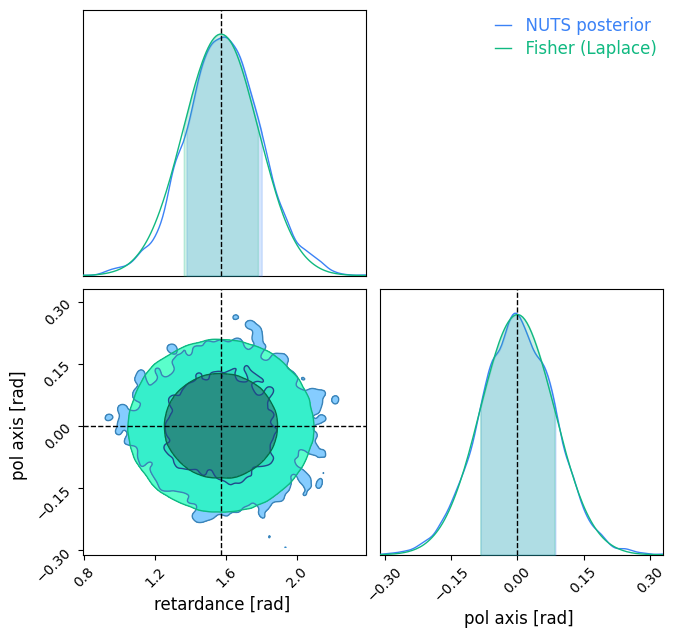

In [127]:
# The Laplace approximation: a Gaussian centred on the MAP with covariance `cov`.
# The mean order must match `cov`, which is in jax sorted-key order:
# [retardance, transmission_axis].
mean = [float(params["retardance"]), float(params["transmission_axis"])]
columns = ["retardance [rad]", "pol axis [rad]"]

cc = ChainConsumer()

# The full NUTS posterior from the Blackjax section...
nuts_df = pd.DataFrame({
    "retardance [rad]": jax.device_get(samples["retardance"]),
    "pol axis [rad]": jax.device_get(samples["transmission_axis"]),
})
cc.add_chain(Chain(samples=nuts_df, name="NUTS posterior"))

# ...overlaid with the Fisher/Laplace Gaussian built straight from the covariance.
cc.add_chain(Chain.from_covariance(mean, cov, columns=columns, name="Fisher (Laplace)"))

cc.add_truth(Truth(location={
    "retardance [rad]": float(np.pi / 2),
    "pol axis [rad]": 0.0,
}))

cc.plotter.plot()
plt.show()


The power of the Fisher information approach lies in its computational efficiency. We can perform maximum likelihood estimation for vastly more parameters for a fraction of the computational cost. However, it comes with the assumption that your _posteriors are indeed gaussian_. Critical to check is if your posterior distribution is multi-modal or otherwise very non-gaussian, the fisher information approach will not be able to capture it.